This notebook contains code to load the ML6 dataset and peform feature selection using splitted traning and testing dataset.
- Train the model without normalization

In [1]:
import sys
sys.path.insert(0, '../')

In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.base import clone

# load local variables
from src.config import *
from src.load_models import select_model
from src.utils import calculate_r2_score, calculate_per_diff, calculate_combined_r2_and_per_diff, per_error, find_adj_score, combine_all_batches, split_batches_back, perform_combat_normalization
from src.feature_selection import ModelSelection
from src.graph_visualization import feature_selection_tabularize


In [3]:
# Load Extracted features dataset
ML6_1 = pd.read_excel('/Users/sangam/Desktop/Epilepsey/Code/vgramreg/dataset/ML6/Day 1 Data/feature_extraction_noise_None.xlsx')
ML6_2 = pd.read_excel('/Users/sangam/Desktop/Epilepsey/Code/vgramreg/dataset/ML6/Day 2 Data/feature_extraction_noise_None.xlsx')

ML6_2['label'] = ML6_2['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))
ML6_2 = ML6_2.drop(columns='file')

ML6_1['label'] = ML6_1['file'].apply(lambda x: x.split('/')[-1].split('_')[-2].replace('cbz','')).apply(lambda x: int(x))
ML6_1 = ML6_1.drop(columns='file')

In [4]:
ML6_1['dataset_name'] = '1'
ML6_2['dataset_name'] = '2'

final_dataset = pd.concat([ML6_1, ML6_2], ignore_index=True)

In [5]:
final_dataset.rename(columns={"PH": 'univariate, max(S)', 'signal_std':'univariate, std(S)', 'signal_mean':'univariate, mean(S)', 'peak area':'univariate, area(S)', \
                        'dS_dV_area':'univariate, area(dS/dV)', 'dS_dV_max_peak':'univariate, max(dS/dV)', 'dS_dV_min_peak':'univariate, min(dS/dV)',\
                    'dS_dV_peak_diff':'univariate, max(dS/dV) - min(dS/dV)', \
                    'peak V':'univariate, V_max(S)', 'dS_dV_max_V':'univariate, V_max(dS/dV)', 'dS_dV_min_V':'univariate, V_min(dS/dV)',\
        }, inplace = True)

Text(0.5, 1.0, 'Box Plot for ML6 1 and 2 datset')

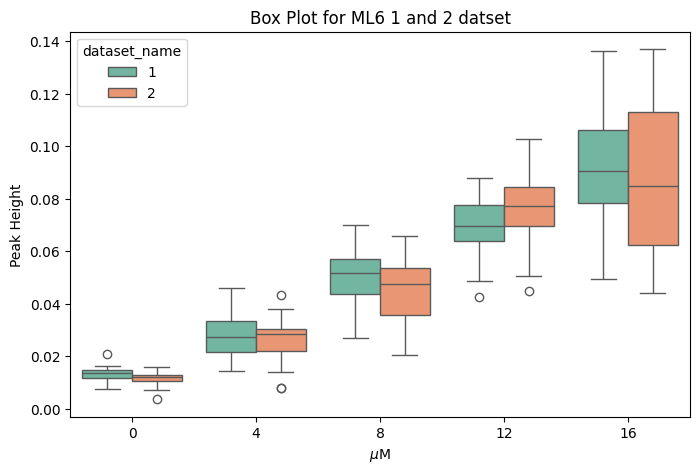

In [6]:
label_order = [0, 4, 8, 12, 16]
plt.figure(figsize=(8, 5))
sns.boxplot(x="label", y="univariate, max(S)", data=final_dataset, hue="dataset_name", palette="Set2", order=label_order)

# Customize the plot
plt.xlabel(r"$\mu $M")
plt.ylabel("Peak Height")
plt.title("Box Plot for ML6 1 and 2 datset")

In [7]:
Y           = final_dataset['label']
X           = final_dataset.drop(columns=['label', 'dataset_name'])

X_train, X_test, y_train, y_test  = train_test_split(X, Y, test_size=0.4, shuffle=True, random_state=42, stratify=Y)

In [8]:
Y.shape

(225,)

In [9]:
# List of models
models = ['Linear', 'KNN', 'SVM', 'RF', 'GP']

# Calcualte y_LOD
y_LOD     = 0.9117010154341669 #calculate_y_LOD(X_testing, y_testing)
kf        = KFold(n_splits=5, shuffle=True, random_state=42)
add_alpha = False

find_class_stratified_score = True

r2_score_val,  per_diff_val  = {'Models':[], 'Scores':[]}, {'Models':[], 'Scores':[]}
r2_score_test, per_diff_test = {'Models':[], 'Scores':[]}, {'Models':[], 'Scores':[]}

r2_score_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}
per_diff_class_stratified_test = {'Models':[], '0':[], '5':[], '8':[], '10':[], '15':[], '16':[]} if add_alpha else {'Models':[], '0':[], '8':[], '16':[]}

for model_name in models:
   
    model             = ModelSelection(model_name, X_train, y_train)
    selected_features = model.find_best_features(kf, r2_score=True)
    df = feature_selection_tabularize(selected_features)

    df.to_excel(f'../results/Journal_paper/Feature_selection/{model_name}_feature_selection.xlsx')
    break
    # print(f"Model Names: {model_name}")
    # print(f"Selected features: {selected_features}")
    

In [20]:
r2        = calculate_r2_score(model.model, X_train, y_train, kf)
per_diff  = calculate_per_diff(model.model, X_train, y_train, kf, y_LOD)

combined  = calculate_combined_r2_and_per_diff(model.model, X_train, y_train, kf, y_LOD, use_adjusted_r2=True)
r2, per_diff, combined

((array(0.83691443), array(0.81939284)),
 31.463942421045182,
 0.5047534138131236)

In [ ]:
model.model

In [ ]:
np.array(a).dtype